# Airline Passenger Forecasting using LSTM



## 1) Imports libraries

Import libraries and set seeds for deterministic behavior where possible.

In [ ]:
import os
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

## 2) Load and Clean Data

Robust loader for common Kaggle `AirPassengers.csv` variants.

In [50]:
# Load dataset
DATA_PATH = r"/kaggle/input/datasets/andreazzini/international-airline-passengers/international-airline-passengers.csv"
df = pd.read_csv(DATA_PATH)
df.head()


,Month,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [51]:
df.rename(columns={'International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60': 'Passengers'}, inplace=True)

In [52]:
df.columns = df.columns.str.strip()
df = df.dropna()

df["Month"] = pd.to_datetime(df["Month"])
df = df.sort_values("Month").reset_index(drop=True)

df.head()

,Month,Passengers
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


## 3) Exploratory Data Analysis

Visualize trend and seasonality in monthly passenger demand.

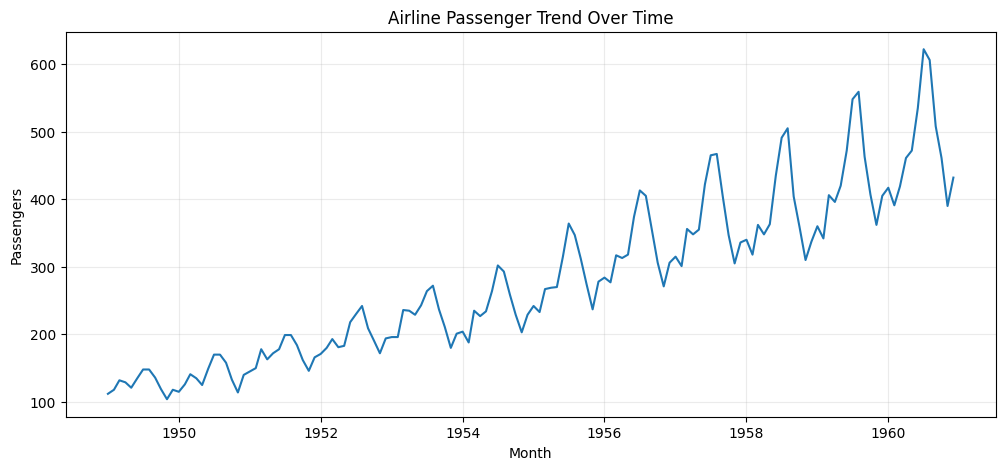

In [53]:
# EDA
plt.figure(figsize=(12, 5))
plt.plot(df["Month"], df["Passengers"], color="tab:blue")
plt.title("Airline Passenger Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.grid(alpha=0.25)
plt.show()

## 4) Time-Aware Train/Test Split

Split chronologically to preserve temporal order.

In [54]:
# Train-test split (time-based)
values = df["Passengers"].values.reshape(-1, 1)
train_size = int(len(values) * 0.8)

train_raw = values[:train_size]
test_raw = values[train_size:]

print("Total samples:", len(values))
print("Train samples:", len(train_raw))
print("Test samples :", len(test_raw))

Total samples: 144
Train samples: 115
Test samples : 29


## 5) Scaling and Sequence Creation

Scale values to `[0, 1]` and construct 12-step supervised sequences.

In [55]:
# Scale without leakage
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled = scaler.transform(test_raw)
all_scaled = np.vstack([train_scaled, test_scaled])

def create_sequences(data, step=12):
    X, y = [], []
    for i in range(len(data) - step):
        X.append(data[i:i+step])
        y.append(data[i+step])
    return np.array(X), np.array(y)

STEP = 12
X_all, y_all = create_sequences(all_scaled, step=STEP)
split_idx = train_size - STEP

X_train, y_train = X_all[:split_idx], y_all[:split_idx]
X_test, y_test = X_all[split_idx:], y_all[split_idx:]

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (103, 12, 1) y_train: (103, 1)
X_test : (29, 12, 1) y_test : (29, 1)


## 6) LSTM Architecture

Stacked LSTM layers with dropout for sequence modeling and regularization.

In [56]:
# Build model
model = Sequential([
    Input(shape=(STEP, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## 7) Model Training Strategy

Train with validation split and callbacks: learning-rate reduction, early stopping, and checkpointing.

In [57]:
# Train model
callbacks = [
    # Control callbacks (single monitor each by design)
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5, verbose=1),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),

    # Save best checkpoints for all key metrics
    ModelCheckpoint("best_model_val_loss.keras", monitor="val_loss", mode="min", save_best_only=True, verbose=1),
    ModelCheckpoint("best_model_val_mae.keras", monitor="val_mae", mode="min", save_best_only=True, verbose=1),
    ModelCheckpoint("best_model_val_rmse.keras", monitor="val_rmse", mode="min", save_best_only=True, verbose=1),
    ModelCheckpoint("best_model_loss.keras", monitor="loss", mode="min", save_best_only=True, verbose=0),
    ModelCheckpoint("best_model_mae.keras", monitor="mae", mode="min", save_best_only=True, verbose=0),
    ModelCheckpoint("best_model_rmse.keras", monitor="rmse", mode="min", save_best_only=True, verbose=0)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
 8/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0607 - mae: 0.2074 - rmse: 0.2457
Epoch 1: val_loss improved from inf to 0.03580, saving model to best_model_val_loss.keras

Epoch 1: val_mae improved from inf to 0.16715, saving model to best_model_val_mae.keras

Epoch 1: val_rmse improved from inf to 0.18921, saving model to best_model_val_rmse.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0539 - mae: 0.1905 - rmse: 0.2308 - val_loss: 0.0358 - val_mae: 0.1671 - val_rmse: 0.1892 - learning_rate: 0.0010
Epoch 2/100
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0258 - mae: 0.1350 - rmse: 0.1597 
Epoch 2: val_loss did not improve from 0.03580

Epoch 2: val_mae did not improve from 0.16715

Epoch 2: val_rmse did not improve from 0.18921
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0243 - mae: 0.1289 - rmse: 0.1548 - val_loss: 0.0692 - val_mae: 0.2115 - val_rmse: 0.2631 - learning_rate: 0.0010
Epoch 3/100
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0103 - m

## 8) Training Curves

Inspect learning dynamics to verify convergence and overfitting behavior.

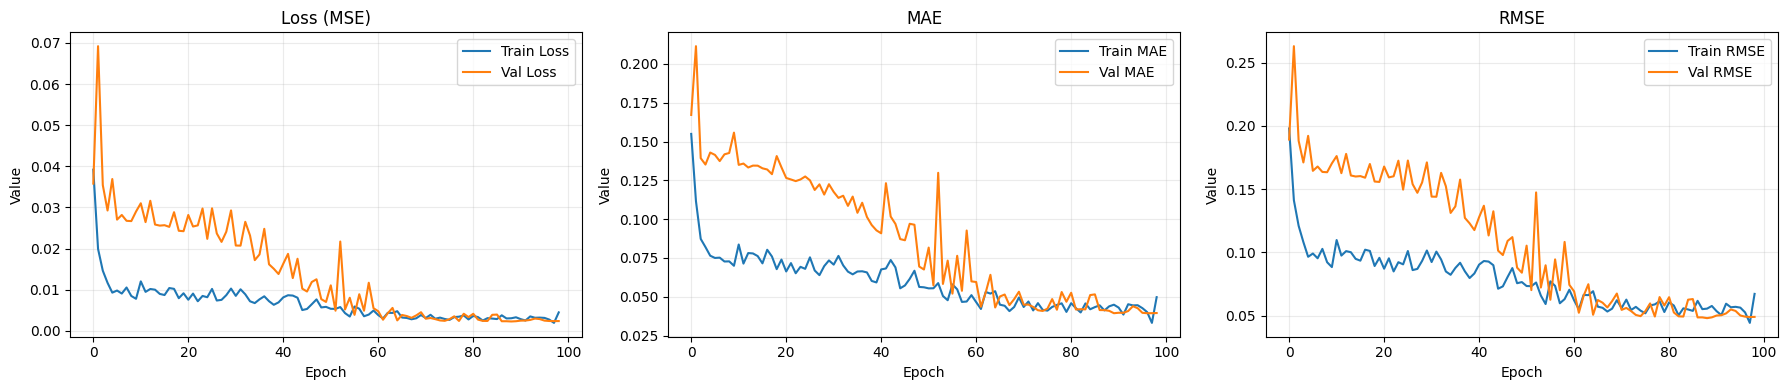

In [58]:
# Training curves (all metrics)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Value")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history.history["mae"], label="Train MAE")
axes[1].plot(history.history["val_mae"], label="Val MAE")
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Value")
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].plot(history.history["rmse"], label="Train RMSE")
axes[2].plot(history.history["val_rmse"], label="Val RMSE")
axes[2].set_title("RMSE")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Value")
axes[2].grid(alpha=0.25)
axes[2].legend()

plt.tight_layout()
plt.show()

## 9) Evaluation Metrics

Compute RMSE and MAE on inverse-scaled predictions.

In [59]:
# Evaluate on test
pred_scaled = model.predict(X_test, verbose=0)
pred = scaler.inverse_transform(pred_scaled)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = math.sqrt(mean_squared_error(y_test_inv, pred))
mae = mean_absolute_error(y_test_inv, pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")

RMSE: 50.558
MAE : 41.502


## 10) Actual vs Predicted Plot

Visual check of test-set fit quality.

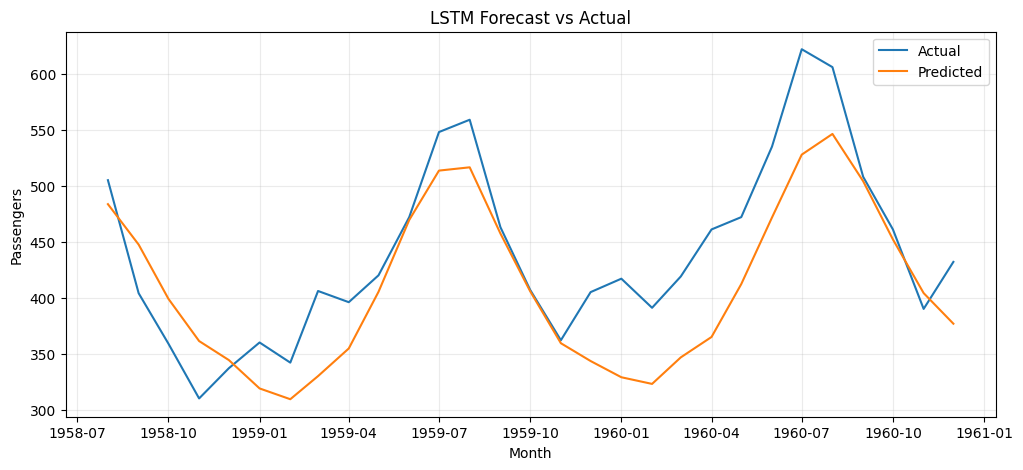

In [60]:
# Actual vs Predicted
test_months = df["Month"].iloc[train_size:].reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(test_months, y_test_inv, label="Actual", color="tab:blue")
plt.plot(test_months, pred, label="Predicted", color="tab:orange")
plt.title("LSTM Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 11) Forecast Next 12 Months

Generate recursive multi-step predictions using the latest observed sequence.

In [61]:
# Future forecast function
def forecast_future(model, last_sequence, scaler, n_future=12):
    future_scaled = []
    seq = last_sequence.copy().reshape(-1, 1)

    for _ in range(n_future):
        x = seq.reshape(1, seq.shape[0], 1)
        next_val = model.predict(x, verbose=0)[0, 0]
        future_scaled.append(next_val)
        seq = np.vstack([seq[1:], [[next_val]]])

    future_scaled = np.array(future_scaled).reshape(-1, 1)
    return scaler.inverse_transform(future_scaled)

last_seq = all_scaled[-STEP:]
future_preds = forecast_future(model, last_seq, scaler, n_future=12)

last_date = df["Month"].iloc[-1]
future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=12, freq="MS")

future_df = pd.DataFrame({
    "Month": future_dates,
    "Forecasted_Passengers": future_preds.flatten().round(2)
})
future_df

,Month,Forecasted_Passengers
0,1961-01-01,340.089996
1,1961-02-01,311.149994
2,1961-03-01,314.859985
3,1961-04-01,331.980011
4,1961-05-01,360.220001
5,1961-06-01,411.279999
6,1961-07-01,470.220001
7,1961-08-01,508.230011
8,1961-09-01,516.450012
9,1961-10-01,515.119995


## 12) Historical + Future Visualization

Compare historical observations with the next 12-month LSTM forecast.

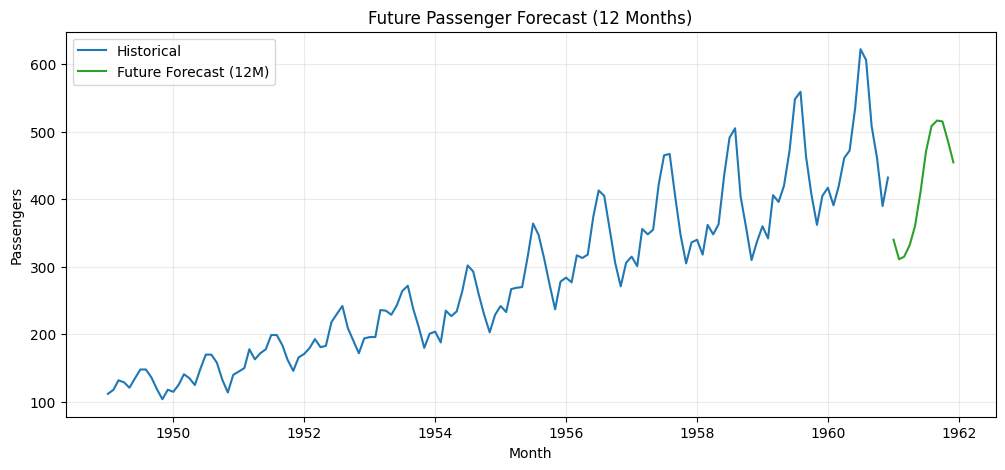

In [62]:
# Plot future forecast
historical = scaler.inverse_transform(all_scaled)

plt.figure(figsize=(12, 5))
plt.plot(df["Month"], historical, label="Historical", color="tab:blue")
plt.plot(future_dates, future_preds, label="Future Forecast (12M)", color="tab:green")
plt.title("Future Passenger Forecast (12 Months)")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 13) Save Forecast Output

Export the future predictions as a CSV file for easy download from Kaggle output files.

In [63]:
# Save outputs (optional)
future_df.to_csv("/kaggle/working/future_passenger_forecast.csv", index=False)
print("Saved: /kaggle/working/future_passenger_forecast.csv")

Saved: /kaggle/working/future_passenger_forecast.csv
